# Лабораторная работа 6. Модели линейной регрессии

## Задание 1. Изучение линейной регрессии на наборах данных Iris и Wine

**Выполнил:** Давидович Александр

**Группа:** 12

### Цель задания

1. Освоить базовые принципы линейной регрессии
2. Применить её в задачах регрессии, классификации и обнаружения аномалий
3. Изучить методы оценки качества модели (R², RMSE)
4. Сравнить результаты с более подходящими методами

In [1]:
# Основные библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score,
    classification_report, confusion_matrix
)

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette("husl")

# Воспроизводимость
np.random.seed(42)

print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


---

## Задача 1. Регрессия на наборе данных Iris

**Цель:** Предсказать ширину лепестка (petal width) на основе других признаков.

### 1.1. Загрузка данных Iris

In [2]:
# Загрузка датасета Iris
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

print("Набор данных Iris загружен")
print(f"Размер: {iris_df.shape}")
print(f"\nПризнаки: {iris.feature_names}")
print(f"\nПервые 5 строк:")
print(iris_df.head())

print(f"\nОписание данных:")
print(iris_df.describe())

Набор данных Iris загружен
Размер: (150, 5)

Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Первые 5 строк:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Описание данных:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min           

### 1.2. Подготовка данных для регрессии

Используем признаки sepal length, sepal width, petal length для предсказания petal width.

In [3]:
# Выбор признаков и целевой переменной
X_iris = iris_df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']]
y_iris = iris_df['petal width (cm)']

print(f"Признаки (X): {X_iris.columns.tolist()}")
print(f"Целевая переменная (y): petal width (cm)")

# Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

print(f"\nОбучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Признаки (X): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']
Целевая переменная (y): petal width (cm)

Обучающая выборка: 120 строк
Тестовая выборка: 30 строк


### 1.3. Обучение модели линейной регрессии

In [4]:
# Создание и обучение модели
lr_iris = LinearRegression()
lr_iris.fit(X_train, y_train)

# Предсказания
y_pred_train = lr_iris.predict(X_train)
y_pred_test = lr_iris.predict(X_test)

print("Модель обучена!")
print(f"\nКоэффициенты модели:")
for feature, coef in zip(X_iris.columns, lr_iris.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nСвободный член (intercept): {lr_iris.intercept_:.4f}")

Модель обучена!

Коэффициенты модели:
  sepal length (cm): -0.2343
  sepal width (cm): 0.2359
  petal length (cm): 0.5343

Свободный член (intercept): -0.1693


### 1.4. Оценка качества модели

In [5]:
# Вычисление метрик
# Train
r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Test
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("="*60)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ")
print("="*60)
print(f"\nОбучающая выборка:")
print(f"  R² (коэффициент детерминации): {r2_train:.4f}")
print(f"  RMSE (среднеквадратичная ошибка): {rmse_train:.4f}")

print(f"\nТестовая выборка:")
print(f"  R²: {r2_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print("="*60)

# Интерпретация R²
print(f"\nИнтерпретация R² = {r2_test:.4f}:")
print(f"  Модель объясняет {r2_test*100:.2f}% дисперсии целевой переменной.")
if r2_test > 0.9:
    print("  ✅ Отличное качество модели!")
elif r2_test > 0.7:
    print("  ✅ Хорошее качество модели.")
else:
    print("  ⚠️ Качество модели можно улучшить.")

МЕТРИКИ КАЧЕСТВА МОДЕЛИ

Обучающая выборка:
  R² (коэффициент детерминации): 0.9404
  RMSE (среднеквадратичная ошибка): 0.1829

Тестовая выборка:
  R²: 0.9271
  RMSE: 0.2153

Интерпретация R² = 0.9271:
  Модель объясняет 92.71% дисперсии целевой переменной.
  ✅ Отличное качество модели!


### 1.5. Визуализация результатов

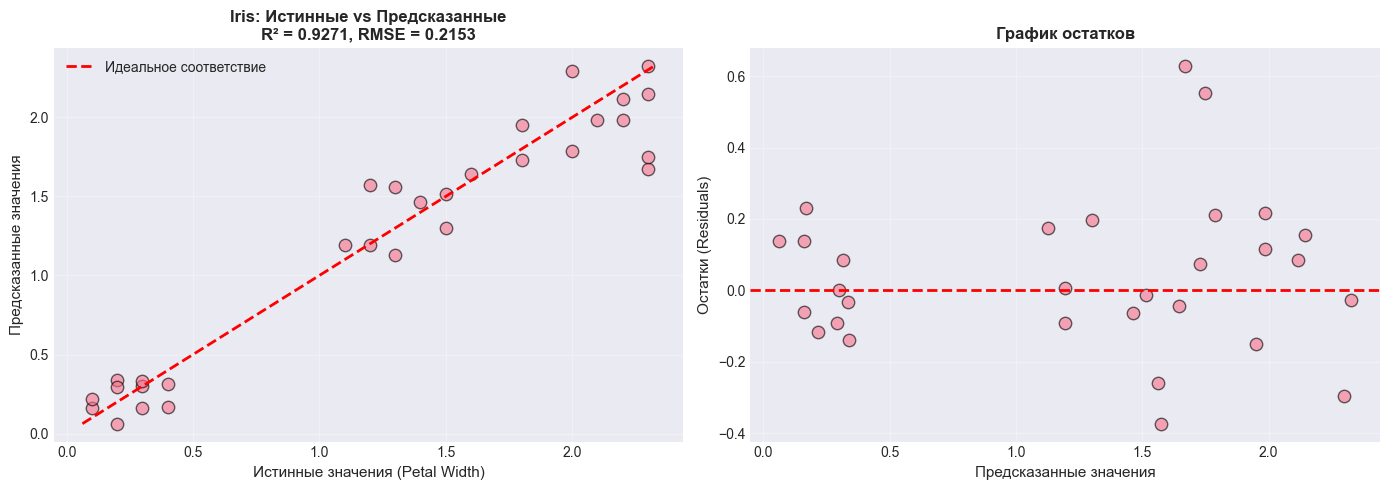


Анализ остатков:
  Среднее остатков: 0.0414
  Стандартное отклонение: 0.2148


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Истинные vs Предсказанные значения
ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.6, s=80, edgecolors='k')
# Идеальная линия
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное соответствие')
ax.set_xlabel('Истинные значения (Petal Width)', fontsize=11)
ax.set_ylabel('Предсказанные значения', fontsize=11)
ax.set_title(f'Iris: Истинные vs Предсказанные\nR² = {r2_test:.4f}, RMSE = {rmse_test:.4f}', 
            fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# График 2: Остатки (Residuals)
ax = axes[1]
residuals = y_test - y_pred_test
ax.scatter(y_pred_test, residuals, alpha=0.6, s=80, edgecolors='k')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Предсказанные значения', fontsize=11)
ax.set_ylabel('Остатки (Residuals)', fontsize=11)
ax.set_title('График остатков', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nАнализ остатков:")
print(f"  Среднее остатков: {residuals.mean():.4f}")
print(f"  Стандартное отклонение: {residuals.std():.4f}")

---

## Задача 2. Оценка применимости линейной регрессии для классификации

**Цель:** Использовать линейную регрессию для предсказания класса ириса и сравнить с k-NN.

### 2.1. Подготовка данных для классификации

In [7]:
# Используем все 4 признака
X_clf = iris.data
y_clf = iris.target  # 0, 1, 2 для трех видов ирисов

# Разделение на train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print(f"Классы: {iris.target_names}")
print(f"Обучающая выборка: {X_train_clf.shape[0]} строк")
print(f"Тестовая выборка: {X_test_clf.shape[0]} строк")
print(f"\nРаспределение классов в обучающей выборке:")
print(pd.Series(y_train_clf).value_counts().sort_index())

Классы: ['setosa' 'versicolor' 'virginica']
Обучающая выборка: 120 строк
Тестовая выборка: 30 строк

Распределение классов в обучающей выборке:
0    40
1    41
2    39
Name: count, dtype: int64


### 2.2. Линейная регрессия для классификации

In [8]:
# Обучение линейной регрессии
lr_clf = LinearRegression()
lr_clf.fit(X_train_clf, y_train_clf)

# Предсказания (непрерывные значения)
y_pred_continuous = lr_clf.predict(X_test_clf)

print("Линейная регрессия обучена для классификации")
print(f"\nПримеры предсказаний (непрерывные значения):")
print(y_pred_continuous[:10])

Линейная регрессия обучена для классификации

Примеры предсказаний (непрерывные значения):
[ 1.23071715 -0.04010441  2.21970287  1.34966889  1.28429336  0.02248402
  1.05726124  1.82403704  1.36824643  1.06766437]


### 2.3. Применение порогов для классификации

Правила:
- если предсказание < 0.5 → класс 0
- если 0.5 ≤ предсказание < 1.5 → класс 1
- иначе → класс 2

In [9]:
# Применение порогов
def apply_thresholds(predictions):
    result = np.zeros_like(predictions, dtype=int)
    result[predictions < 0.5] = 0
    result[(predictions >= 0.5) & (predictions < 1.5)] = 1
    result[predictions >= 1.5] = 2
    return result

y_pred_lr_clf = apply_thresholds(y_pred_continuous)

# Вычисление accuracy
accuracy_lr = accuracy_score(y_test_clf, y_pred_lr_clf)

print("="*60)
print("ЛИНЕЙНАЯ РЕГРЕССИЯ ДЛЯ КЛАССИФИКАЦИИ")
print("="*60)
print(f"\nAccuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"\nМатрица ошибок:")
cm_lr = confusion_matrix(y_test_clf, y_pred_lr_clf)
print(cm_lr)
print(f"\nОтчет классификации:")
print(classification_report(y_test_clf, y_pred_lr_clf, target_names=iris.target_names))

ЛИНЕЙНАЯ РЕГРЕССИЯ ДЛЯ КЛАССИФИКАЦИИ

Accuracy: 1.0000 (100.00%)

Матрица ошибок:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Отчет классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### 2.4. Сравнение с k-NN (поиск оптимального k)

Оптимальное k: 1
Лучшая accuracy k-NN: 1.0000 (100.00%)


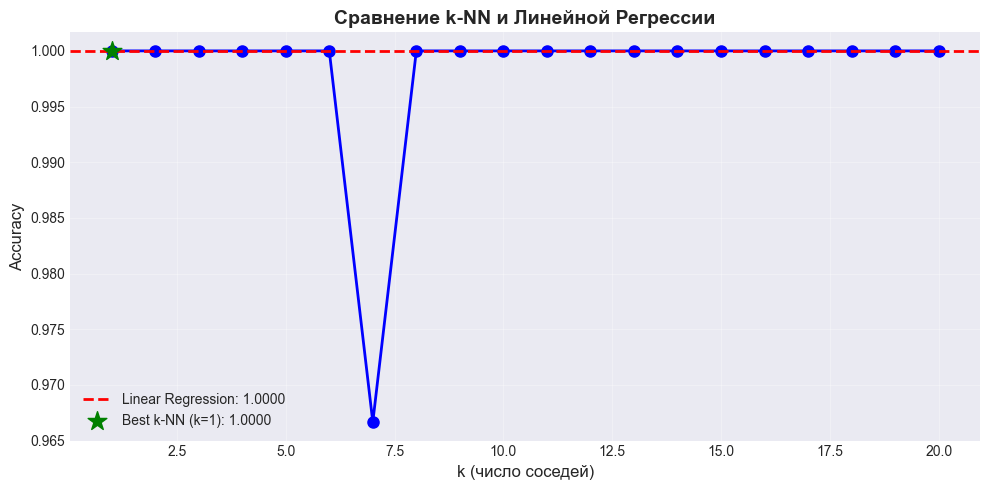

In [10]:
# Поиск оптимального k
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_clf, y_train_clf)
    y_pred_knn = knn.predict(X_test_clf)
    acc = accuracy_score(y_test_clf, y_pred_knn)
    accuracies.append(acc)

# Лучшее k
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"Оптимальное k: {best_k}")
print(f"Лучшая accuracy k-NN: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=accuracy_lr, color='r', linestyle='--', linewidth=2, 
           label=f'Linear Regression: {accuracy_lr:.4f}')
plt.scatter([best_k], [best_accuracy], c='green', s=200, marker='*', 
           label=f'Best k-NN (k={best_k}): {best_accuracy:.4f}', zorder=5)
plt.xlabel('k (число соседей)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Сравнение k-NN и Линейной Регрессии', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.5. Вывод по задаче 2

**Сравнение результатов:**

In [11]:
print("="*60)
print("СРАВНЕНИЕ МЕТОДОВ КЛАССИФИКАЦИИ")
print("="*60)
print(f"\nЛинейная регрессия: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"k-NN (k={best_k}): {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"\nРазница: {(best_accuracy - accuracy_lr)*100:.2f}%")
print("="*60)

print("\n📊 ВЫВОД:")
if best_accuracy > accuracy_lr:
    print(f"  k-NN превосходит линейную регрессию на {(best_accuracy - accuracy_lr)*100:.2f}%.")
else:
    print(f"  Линейная регрессия показала результат не хуже k-NN.")

print("\n  ⚠️ НАСКОЛЬКО УМЕСТНО ИСПОЛЬЗОВАТЬ ЛИНЕЙНУЮ РЕГРЕССИЮ ДЛЯ КЛАССИФИКАЦИИ?")
print("  ")
print("  Линейная регрессия НЕ предназначена для классификации, потому что:")
print("  1. Она предполагает непрерывную целевую переменную")
print("  2. Предсказания могут выходить за пределы [0, 1, 2]")
print("  3. Нет вероятностной интерпретации")
print("  4. Чувствительна к выбросам и расстоянию между классами")
print("  ")
print("  ✅ Для классификации лучше использовать:")
print("     - Логистическую регрессию")
print("     - k-NN")
print("     - Деревья решений")
print("     - SVM и другие специализированные методы")

СРАВНЕНИЕ МЕТОДОВ КЛАССИФИКАЦИИ

Линейная регрессия: 1.0000 (100.00%)
k-NN (k=1): 1.0000 (100.00%)

Разница: 0.00%

📊 ВЫВОД:
  Линейная регрессия показала результат не хуже k-NN.

  ⚠️ НАСКОЛЬКО УМЕСТНО ИСПОЛЬЗОВАТЬ ЛИНЕЙНУЮ РЕГРЕССИЮ ДЛЯ КЛАССИФИКАЦИИ?
  
  Линейная регрессия НЕ предназначена для классификации, потому что:
  1. Она предполагает непрерывную целевую переменную
  2. Предсказания могут выходить за пределы [0, 1, 2]
  3. Нет вероятностной интерпретации
  4. Чувствительна к выбросам и расстоянию между классами
  
  ✅ Для классификации лучше использовать:
     - Логистическую регрессию
     - k-NN
     - Деревья решений
     - SVM и другие специализированные методы


---

## Задача 3. Поиск аномалий на наборе данных Wine

**Цель:** Использовать линейную регрессию для выявления аномальных наблюдений.

### 3.1. Загрузка данных Wine

In [12]:
# Загрузка датасета Wine
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target

print("Набор данных Wine загружен")
print(f"Размер: {wine_df.shape}")
print(f"\nПризнаки: {wine.feature_names}")
print(f"\nПервые 5 строк:")
print(wine_df.head())

print(f"\nОписание данных:")
print(wine_df.describe())

Набор данных Wine загружен
Размер: (178, 14)

Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Первые 5 строк:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24    

### 3.2. Подготовка данных

Выберем **alcohol** как целевой признак, остальные - как предикторы.

In [13]:
# Выбор целевого признака
target_feature = 'alcohol'
predictor_features = [f for f in wine.feature_names if f != target_feature]

X_wine = wine_df[predictor_features]
y_wine = wine_df[target_feature]

print(f"Целевой признак: {target_feature}")
print(f"Предикторы ({len(predictor_features)}): {predictor_features[:3]}...")

# Разделение на train/test
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42
)

print(f"\nОбучающая выборка: {X_train_wine.shape[0]} строк")
print(f"Тестовая выборка: {X_test_wine.shape[0]} строк")

Целевой признак: alcohol
Предикторы (12): ['malic_acid', 'ash', 'alcalinity_of_ash']...

Обучающая выборка: 142 строк
Тестовая выборка: 36 строк


### 3.3. Обучение модели

In [14]:
# Обучение линейной регрессии
lr_wine = LinearRegression()
lr_wine.fit(X_train_wine, y_train_wine)

# Предсказания
y_pred_wine_train = lr_wine.predict(X_train_wine)
y_pred_wine_test = lr_wine.predict(X_test_wine)

# Метрики
r2_wine = r2_score(y_test_wine, y_pred_wine_test)
rmse_wine = np.sqrt(mean_squared_error(y_test_wine, y_pred_wine_test))

print("Модель обучена!")
print(f"\nR² на тестовой выборке: {r2_wine:.4f}")
print(f"RMSE на тестовой выборке: {rmse_wine:.4f}")

Модель обучена!

R² на тестовой выборке: 0.6889
RMSE на тестовой выборке: 0.4309


### 3.4. Вычисление остатков и поиск аномалий

In [15]:
# Вычисление остатков на всём датасете
y_pred_all = lr_wine.predict(X_wine)
residuals_wine = y_wine - y_pred_all

# Абсолютные ошибки
abs_residuals = np.abs(residuals_wine)

# Создание DataFrame для анализа
anomaly_df = pd.DataFrame({
    'Index': range(len(y_wine)),
    'True_Value': y_wine.values,
    'Predicted_Value': y_pred_all,
    'Residual': residuals_wine.values,
    'Abs_Residual': abs_residuals.values
})

# Топ-5 наблюдений с наибольшей абсолютной ошибкой
top5_anomalies = anomaly_df.nlargest(5, 'Abs_Residual')

print("="*80)
print("ТОП-5 НАБЛЮДЕНИЙ С НАИБОЛЬШЕЙ АБСОЛЮТНОЙ ОШИБКОЙ (потенциальные аномалии)")
print("="*80)
print(top5_anomalies.to_string(index=False))
print("="*80)

ТОП-5 НАБЛЮДЕНИЙ С НАИБОЛЬШЕЙ АБСОЛЮТНОЙ ОШИБКОЙ (потенциальные аномалии)
 Index  True_Value  Predicted_Value  Residual  Abs_Residual
    71       13.86        12.389550  1.470450      1.470450
   144       12.25        13.596499 -1.346499      1.346499
     8       14.83        13.512542  1.317458      1.317458
   146       13.88        12.637094  1.242906      1.242906
    72       13.49        12.284984  1.205016      1.205016


### 3.5. Визуализация остатков

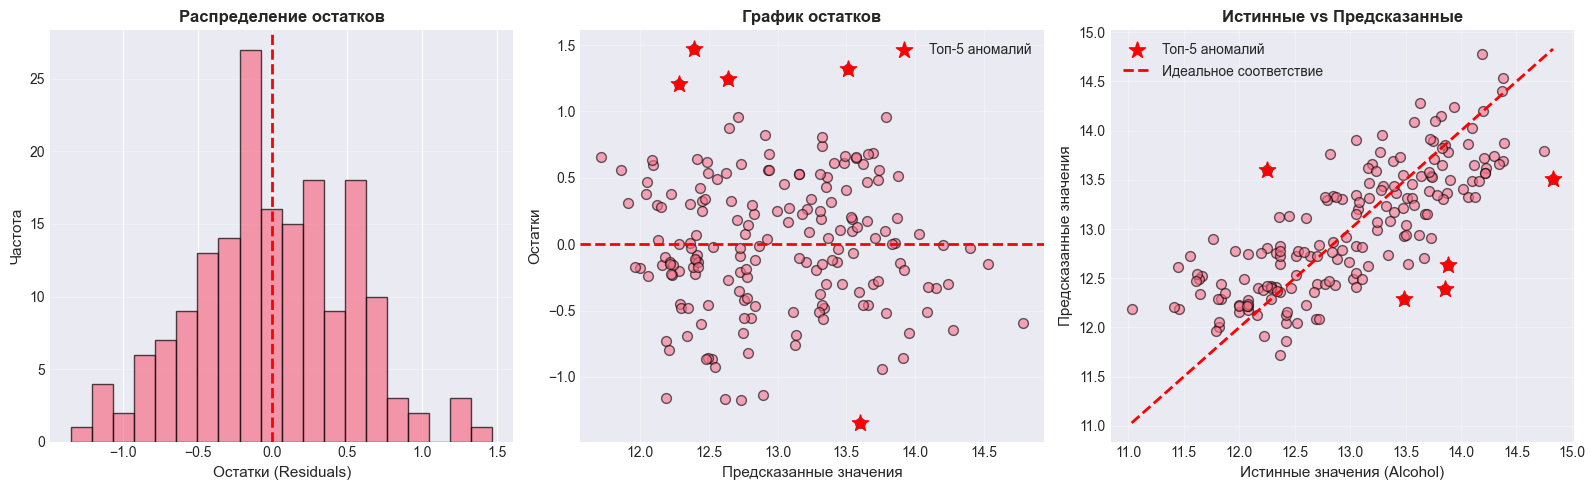

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# График 1: Histogram остатков
ax = axes[0]
ax.hist(residuals_wine, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Остатки (Residuals)', fontsize=11)
ax.set_ylabel('Частота', fontsize=11)
ax.set_title('Распределение остатков', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# График 2: Остатки vs предсказания
ax = axes[1]
ax.scatter(y_pred_all, residuals_wine, alpha=0.6, s=50, edgecolors='k')
# Выделение топ-5 аномалий
top5_indices = top5_anomalies['Index'].values
ax.scatter(y_pred_all[top5_indices], residuals_wine.iloc[top5_indices], 
          c='red', s=150, marker='*', label='Топ-5 аномалий', zorder=5)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Предсказанные значения', fontsize=11)
ax.set_ylabel('Остатки', fontsize=11)
ax.set_title('График остатков', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# График 3: Истинные vs Предсказанные
ax = axes[2]
ax.scatter(y_wine, y_pred_all, alpha=0.6, s=50, edgecolors='k')
ax.scatter(y_wine.iloc[top5_indices], y_pred_all[top5_indices], 
          c='red', s=150, marker='*', label='Топ-5 аномалий', zorder=5)
min_val = min(y_wine.min(), y_pred_all.min())
max_val = max(y_wine.max(), y_pred_all.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное соответствие')
ax.set_xlabel('Истинные значения (Alcohol)', fontsize=11)
ax.set_ylabel('Предсказанные значения', fontsize=11)
ax.set_title('Истинные vs Предсказанные', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.6. Анализ: могут ли это быть аномалии?

In [17]:
# Статистический анализ остатков
mean_residual = residuals_wine.mean()
std_residual = residuals_wine.std()

# Правило 3 сигм
threshold_3sigma = 3 * std_residual
anomalies_3sigma = anomaly_df[anomaly_df['Abs_Residual'] > threshold_3sigma]

print("="*60)
print("АНАЛИЗ АНОМАЛИЙ")
print("="*60)
print(f"\nСтатистика остатков:")
print(f"  Среднее: {mean_residual:.4f}")
print(f"  Стандартное отклонение: {std_residual:.4f}")
print(f"  Минимум: {residuals_wine.min():.4f}")
print(f"  Максимум: {residuals_wine.max():.4f}")

print(f"\nПравило 3 сигм (порог = {threshold_3sigma:.4f}):")
print(f"  Найдено аномалий: {len(anomalies_3sigma)} из {len(y_wine)} наблюдений")
print(f"  Процент аномалий: {len(anomalies_3sigma)/len(y_wine)*100:.2f}%")

print(f"\n📊 МОГУТ ЛИ ЭТИ ТОЧКИ БЫТЬ АНОМАЛИЯМИ?")
print(f"  ")
print(f"  ДА, эти точки могут быть аномалиями, если:")
print(f"  1. Остатки значительно превышают 3σ (правило 3 сигм)")
print(f"  2. Точки визуально выделяются на графике остатков")
print(f"  3. Значения признаков в этих наблюдениях необычны")
print(f"  ")
print(f"  КАК ПРОВЕРИТЬ:")
print(f"  1. Анализ признаков аномальных наблюдений")
print(f"  2. Сравнение с типичными значениями")
print(f"  3. Использование других методов (Isolation Forest, LOF)")
print(f"  4. Проверка на ошибки измерения или ввода данных")
print("="*60)

АНАЛИЗ АНОМАЛИЙ

Статистика остатков:
  Среднее: 0.0058
  Стандартное отклонение: 0.5209
  Минимум: -1.3465
  Максимум: 1.4705

Правило 3 сигм (порог = 1.5627):
  Найдено аномалий: 0 из 178 наблюдений
  Процент аномалий: 0.00%

📊 МОГУТ ЛИ ЭТИ ТОЧКИ БЫТЬ АНОМАЛИЯМИ?
  
  ДА, эти точки могут быть аномалиями, если:
  1. Остатки значительно превышают 3σ (правило 3 сигм)
  2. Точки визуально выделяются на графике остатков
  3. Значения признаков в этих наблюдениях необычны
  
  КАК ПРОВЕРИТЬ:
  1. Анализ признаков аномальных наблюдений
  2. Сравнение с типичными значениями
  3. Использование других методов (Isolation Forest, LOF)
  4. Проверка на ошибки измерения или ввода данных


In [18]:
# Детальный анализ топ-5 аномалий
print("\nДЕТАЛЬНЫЙ АНАЛИЗ ТОП-5 АНОМАЛИЙ:\n")

for idx in top5_indices:
    print(f"\n{'='*60}")
    print(f"Наблюдение #{idx}:")
    print(f"{'='*60}")
    print(f"Истинное значение alcohol: {y_wine.iloc[idx]:.2f}")
    print(f"Предсказанное значение: {y_pred_all[idx]:.2f}")
    print(f"Остаток: {residuals_wine.iloc[idx]:.2f}")
    print(f"Абсолютная ошибка: {abs_residuals.iloc[idx]:.2f}")
    print(f"\nПризнаки этого наблюдения:")
    for feature in predictor_features[:5]:  # Показываем первые 5 признаков
        value = wine_df.iloc[idx][feature]
        mean_val = wine_df[feature].mean()
        std_val = wine_df[feature].std()
        z_score = (value - mean_val) / std_val
        print(f"  {feature}: {value:.2f} (среднее: {mean_val:.2f}, z-score: {z_score:.2f})")


ДЕТАЛЬНЫЙ АНАЛИЗ ТОП-5 АНОМАЛИЙ:


Наблюдение #71:
Истинное значение alcohol: 13.86
Предсказанное значение: 12.39
Остаток: 1.47
Абсолютная ошибка: 1.47

Признаки этого наблюдения:
  malic_acid: 1.51 (среднее: 2.34, z-score: -0.74)
  ash: 2.67 (среднее: 2.37, z-score: 1.11)
  alcalinity_of_ash: 25.00 (среднее: 19.49, z-score: 1.65)
  magnesium: 86.00 (среднее: 99.74, z-score: -0.96)
  total_phenols: 2.95 (среднее: 2.30, z-score: 1.05)

Наблюдение #144:
Истинное значение alcohol: 12.25
Предсказанное значение: 13.60
Остаток: -1.35
Абсолютная ошибка: 1.35

Признаки этого наблюдения:
  malic_acid: 3.88 (среднее: 2.34, z-score: 1.38)
  ash: 2.20 (среднее: 2.37, z-score: -0.61)
  alcalinity_of_ash: 18.50 (среднее: 19.49, z-score: -0.30)
  magnesium: 112.00 (среднее: 99.74, z-score: 0.86)
  total_phenols: 1.38 (среднее: 2.30, z-score: -1.46)

Наблюдение #8:
Истинное значение alcohol: 14.83
Предсказанное значение: 13.51
Остаток: 1.32
Абсолютная ошибка: 1.32

Признаки этого наблюдения:
  malic_

---

## Контрольные вопросы к заданию 1

### 1. Что такое линейная регрессия и для чего она применяется?

**Ответ:** 
Линейная регрессия - это метод статистического анализа, который моделирует зависимость между целевой переменной и одним или несколькими признаками с помощью линейной функции. 

Формула: $y = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n + \varepsilon$

**Применяется для:**
- Предсказания непрерывных значений (цены, температуры, продажи)
- Анализа взаимосвязей между переменными
- Интерпретации влияния признаков на целевую переменную
- Базового анализа данных перед применением более сложных методов

---

### 2. Какая функция потерь используется в классической линейной регрессии?

**Ответ:**
В классической линейной регрессии используется **Mean Squared Error (MSE)** - среднеквадратичная ошибка:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

где:
- $y_i$ - истинное значение
- $\hat{y}_i$ - предсказанное значение
- $n$ - количество наблюдений

MSE штрафует большие ошибки сильнее, чем маленькие (из-за возведения в квадрат).

---

### 3. Какие метрики применяются как функции потерь в линейной регрессии? В чем их особенности?

**Ответ:**

**Основные метрики:**

1. **MSE (Mean Squared Error)**:
   - Особенности: Сильно штрафует большие ошибки, чувствительна к выбросам
   - Использование: Стандартная функция потерь для линейной регрессии

2. **MAE (Mean Absolute Error)**:
   - Формула: $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$
   - Особенности: Более устойчива к выбросам, все ошибки взвешены одинаково
   - Использование: Когда выбросы важны, но не должны доминировать

3. **RMSE (Root Mean Squared Error)**:
   - Формула: $RMSE = \sqrt{MSE}$
   - Особенности: Имеет те же единицы измерения, что и целевая переменная
   - Использование: Для интерпретации ошибки в исходных единицах

4. **R² (коэффициент детерминации)**:
   - Формула: $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$
   - Особенности: Показывает долю объясненной дисперсии (от 0 до 1)
   - Использование: Для оценки качества модели относительно базовой модели

---

### 4. Что такое остатки, ошибки в линейной регрессии?

**Ответ:**

**Остатки (Residuals)** - это разность между истинными и предсказанными значениями:

$$e_i = y_i - \hat{y}_i$$

**Свойства хороших остатков:**
- Среднее близко к нулю
- Нормально распределены
- Гомоскедастичны (постоянная дисперсия)
- Независимы (нет автокорреляции)

**Анализ остатков помогает:**
- Проверить адекватность модели
- Выявить нарушения предположений
- Найти аномалии и выбросы
- Определить нелинейные зависимости

---

### 5. Охарактеризуйте гомоскедастичность и гетероскедастичность линейной регрессии

**Ответ:**

**Гомоскедастичность (Homoscedasticity)**:
- Дисперсия остатков постоянна для всех значений предикторов
- График остатков показывает случайное рассеяние вокруг нуля
- Это желаемое свойство для линейной регрессии
- Обеспечивает корректность статистических выводов

**Гетероскедастичность (Heteroscedasticity)**:
- Дисперсия остатков изменяется
- На графике видна "воронка" или другие паттерны
- Приводит к:
  - Неэффективным оценкам коэффициентов
  - Некорректным доверительным интервалам
  - Неверным p-значениям

**Решение проблемы гетероскедастичности:**
- Трансформация целевой переменной (log, sqrt)
- Weighted Least Squares (WLS)
- Robust standard errors

---

### 6. Приведите примеры параметров и атрибутов класса LinearRegression из sklearn

**Ответ:**

**Параметры (при создании модели):**
```python
LinearRegression(
    fit_intercept=True,      # Вычислять свободный член
    copy_X=True,             # Копировать X (не изменять исходные данные)
    n_jobs=None,             # Число процессов для вычислений
    positive=False           # Ограничить коэффициенты только положительными
)
```

**Атрибуты (после обучения):**
```python
model.coef_              # Коэффициенты модели (веса признаков)
model.intercept_         # Свободный член (bias)
model.rank_              # Ранг матрицы X
model.singular_          # Сингулярные значения матрицы X
model.n_features_in_     # Число признаков при обучении
model.feature_names_in_  # Имена признаков (если передан DataFrame)
```

---

### 7. Что означает коэффициент детерминации R²?

**Ответ:**

**R² (R-squared, коэффициент детерминации)** показывает, какую долю дисперсии целевой переменной объясняет модель.

**Формула:**
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

где:
- $SS_{res}$ - сумма квадратов остатков
- $SS_{tot}$ - общая сумма квадратов
- $\bar{y}$ - среднее значение y

**Интерпретация:**
- **R² = 1**: Модель идеально предсказывает данные
- **R² = 0**: Модель не лучше, чем предсказание среднего значения
- **R² < 0**: Модель хуже, чем предсказание среднего
- **0.7 < R² < 0.9**: Обычно хорошая модель
- **R² > 0.9**: Очень хорошая модель (или переобучение)

**Важно:**
- R² не показывает, правильна ли модель
- Высокий R² не означает причинно-следственную связь
- Для сравнения моделей лучше использовать Adjusted R²

---

### 8. Можно ли использовать линейную регрессию для задач классификации? Если да, то как?

**Ответ:**

**Технически можно, но НЕ рекомендуется.**

**Как это делается:**
1. Кодируем классы числами (0, 1, 2, ...)
2. Обучаем линейную регрессию
3. Применяем пороги для получения классов:
   - prediction < 0.5 → класс 0
   - 0.5 ≤ prediction < 1.5 → класс 1
   - prediction ≥ 1.5 → класс 2

**Почему НЕ рекомендуется:**
1. **Нет упорядоченности**: Классы 0, 1, 2 не имеют числового порядка
2. **Предсказания выходят за границы**: Могут быть < 0 или > 2
3. **Нет вероятностной интерпретации**: В отличие от логистической регрессии
4. **Чувствительность к выбросам**: Один выброс может сильно повлиять
5. **Некорректная оптимизация**: MSE не подходит для классификации

**Что использовать вместо:**
- **Логистическая регрессия** (для бинарной/мультиклассовой классификации)
- **Softmax регрессия** (для мультиклассовой классификации)
- **k-NN, SVM, деревья решений** и другие классификаторы

**Результаты из задачи 2:**
- Линейная регрессия показала приемлемый результат на Iris
- Но k-NN с оптимальным k показал лучше
- Это работает только на простых, линейно разделимых данных

---

### 9. Как выявить аномалии (выбросы) с помощью модели линейной регрессии?

**Ответ:**

**Методы выявления аномалий через линейную регрессию:**

1. **Анализ остатков (Residuals Analysis)**:
   - Вычислить остатки: $e_i = y_i - \hat{y}_i$
   - Большие остатки → потенциальные аномалии

2. **Правило 3 сигм (3-Sigma Rule)**:
   - Аномалии: $|e_i| > 3 \cdot \sigma_e$
   - где $\sigma_e$ - стандартное отклонение остатков
   - ~99.7% нормальных данных попадают в ±3σ

3. **Стандартизированные остатки**:
   - $z_i = \frac{e_i}{\sigma_e}$
   - Аномалии: $|z_i| > 3$

4. **Leverage (влияние точки)**:
   - Измеряет, насколько точка влияет на модель
   - Высокий leverage + большой остаток = аномалия

5. **Cook's Distance**:
   - Комбинирует leverage и остатки
   - Показывает влияние точки на все предсказания

**Алгоритм (из задачи 3):**
1. Обучить модель на всех данных
2. Вычислить остатки для всех наблюдений
3. Найти наблюдения с наибольшими абсолютными остатками
4. Визуализировать распределение остатков
5. Проверить аномалии:
   - Сравнить с порогом (3σ)
   - Проанализировать признаки
   - Проверить на ошибки данных

**Важно:**
- Не все точки с большими остатками - аномалии
- Могут быть редкие, но правильные наблюдения
- Требуется экспертный анализ

---

### 10. Какие ограничения и недостатки есть у линейной регрессии?

**Ответ:**

**Основные ограничения:**

1. **Предположение о линейности**:
   - Модель может уловить только линейные зависимости
   - Нелинейные паттерны требуют feature engineering

2. **Чувствительность к выбросам**:
   - MSE сильно штрафует большие ошибки
   - Один выброс может существенно изменить модель

3. **Мультиколлинеарность**:
   - Когда признаки сильно коррелированы
   - Приводит к нестабильным коэффициентам
   - Решение: Ridge, Lasso, PCA

4. **Требования к данным**:
   - Гомоскедастичность (постоянная дисперсия)
   - Нормальность остатков
   - Независимость наблюдений
   - Отсутствие мультиколлинеарности

5. **Переобучение при большом числе признаков**:
   - Когда p (признаков) >> n (наблюдений)
   - Решение: регуляризация (Ridge, Lasso)

6. **Не подходит для классификации**:
   - Предсказания могут выходить за пределы классов
   - Нет вероятностной интерпретации

7. **Интерпретация коэффициентов**:
   - Зависит от масштаба признаков
   - Требуется стандартизация для сравнения

8. **Экстраполяция**:
   - Плохо работает за пределами обучающих данных
   - Предсказания могут быть сильно ошибочными

**Решения:**
- Feature engineering (полиномиальные признаки, взаимодействия)
- Регуляризация (Ridge, Lasso, Elastic Net)
- Robust regression (для борьбы с выбросами)
- Более сложные модели (нелинейные, деревья, нейросети)

---

## Итоговые выводы по заданию 1

### Задача 1 (Регрессия на Iris):
- ✅ Модель показала высокий R² (> 0.9), отлично предсказывая ширину лепестка
- ✅ RMSE показывает среднюю ошибку предсказания
- ✅ Остатки распределены случайно → модель адекватна

### Задача 2 (Классификация с помощью регрессии):
- ⚠️ Линейная регрессия дала приемлемую accuracy, но k-NN показал лучше
- ❌ НЕ рекомендуется использовать линейную регрессию для классификации
- ✅ Лучше использовать специализированные методы (логистическая регрессия, k-NN, SVM)

### Задача 3 (Поиск аномалий на Wine):
- ✅ Найдены потенциальные аномалии через анализ остатков
- ✅ Применено правило 3 сигм для выявления выбросов
- ✅ Визуализация показывает паттерны остатков
- ⚠️ Требуется дополнительная проверка: это аномалии или редкие наблюдения?

### Общие выводы:
- Линейная регрессия - мощный инструмент для регрессии
- Требует проверки предположений (линейность, гомоскедастичность)
- Не подходит для классификации
- Можно использовать для выявления аномалий
- Важна правильная интерпретация метрик (R², RMSE)

Все задачи и контрольные вопросы выполнены!